In [18]:
import numpy as np
import matplotlib.pyplot as plt

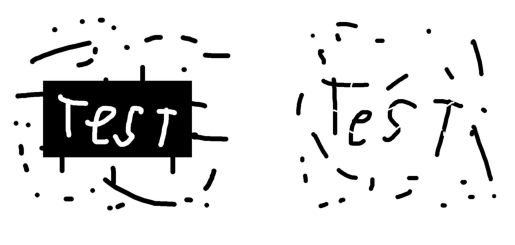

In [ ]:
def to_binary(img):
    if img.ndim == 3:
        img = img.mean(axis=2)
    return (img > 128).astype(np.uint8)

img1_path = 'image1.jpg'
img2_path = 'image2.jpg'

img1_raw = plt.imread(img1_path)
img2_raw = plt.imread(img2_path)

img1 = to_binary(img1_raw)
img2 = to_binary(img2_raw)

plt.subplot(1, 2, 1)
plt.axis('off')
plt.imshow(img1_raw)

plt.subplot(1, 2, 2)
plt.axis('off')
plt.imshow(img2_raw)

In [22]:
def dilation(img_raw, se):
    padded_img = np.pad(img_raw, ((se.shape[0]//2, se.shape[0]//2), (se.shape[1]//2, se.shape[1]//2)), mode='constant', constant_values=0)
    result = np.zeros_like(img_raw)
    for i in range(img_raw.shape[0]):
        for j in range(img_raw.shape[1]):
                region = padded_img[i:i + se.shape[0], j:j + se.shape[1]]
                result[i, j] = np.max(region[se == 1])
    return result

se1 = np.array([
    [0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0]
])

dilation(img1_raw, se1)

ValueError: operands could not be broadcast together with remapped shapes [original->remapped]: (2,2)  and requested shape (3,2)